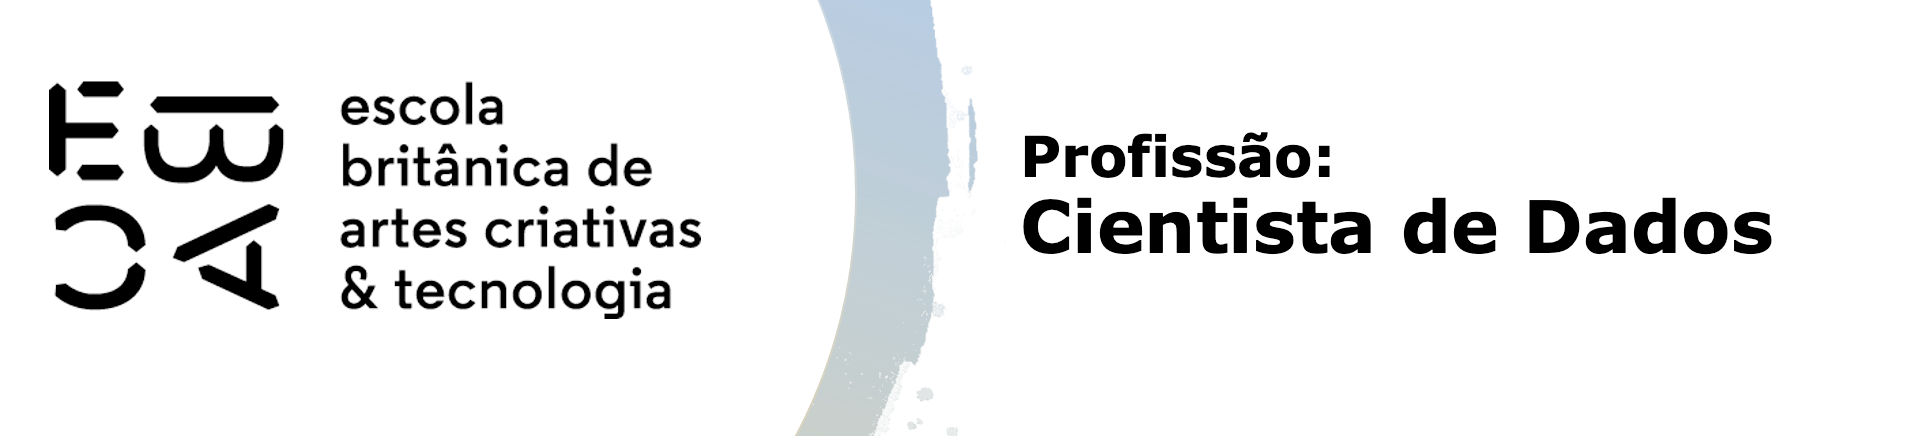

# Tarefa II

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import plotly.express as px
from sklearn import metrics
from scipy.stats import ks_2samp
from scipy.stats import t

In [7]:
df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [8]:
df.shape

(750000, 15)

## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [9]:
# Separar os três últimos meses para validação out-of-time
unique_dates = df.data_ref.sort_values().unique()
dev_dates = unique_dates[:-3]
oot_dates = unique_dates[-3:]

In [10]:
# Separar bases de desenvolvimento e out-of-time
df_dev = df[df.data_ref.isin(dev_dates)].copy()
df_oot = df[df.data_ref.isin(oot_dates)].copy()

In [11]:
# Verificar número de registros
print("Base desenvolvimento:", df_dev.shape[0])
print("Base out-of-time:", df_oot.shape[0])

Base desenvolvimento: 600000
Base out-of-time: 150000


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [12]:
df_dev['data_ref'] = df_dev['idade'] / (df_dev['qtd_filhos'] - df_dev['tempo_emprego'])
df_dev.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,-6.255480,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,-7.733051,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,17.652106,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,-4.227799,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,-3.676088,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [13]:
df_dev.describe()

,data_ref,index,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
count,499125.000000,600000.000000,600000.000000,600000.000000,499125.000000,600000.000000,6.000000e+05
mean,-11.726826,8322.563235,0.433210,43.798530,7.747992,2.212122,2.722284e+04
std,195.598361,4810.120431,0.739869,11.230659,6.688576,0.903757,8.737788e+04
min,-6205.000000,0.000000,0.000000,22.000000,0.117808,1.000000,1.618600e+02
25%,-12.909154,4147.000000,0.000000,34.000000,3.049315,2.000000,4.670600e+03
50%,-6.263651,8330.000000,0.000000,43.000000,6.046575,2.000000,9.887580e+03
75%,-3.626042,12494.000000,1.000000,53.000000,10.180822,3.000000,2.162887e+04
max,3893.333333,16649.000000,14.000000,68.000000,42.906849,15.000000,4.083986e+06


<Axes: ylabel='Frequency'>

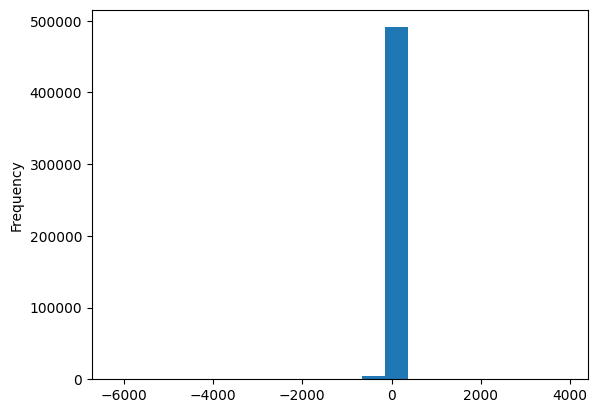

In [14]:
df_dev['data_ref'].plot.hist(bins = 20)

## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

In [15]:
def IV(variavel, resposta):
    tab = pd.crosstab(variavel, resposta, margins=True, margins_name='total')

    rótulo_evento = tab.columns[0]
    rótulo_nao_evento = tab.columns[1]

    tab['pct_evento'] = tab[rótulo_evento]/tab.loc['total',rótulo_evento]
    tab['ep'] = tab[rótulo_evento]/tab.loc['total',rótulo_evento]

    tab['pct_nao_evento'] = tab[rótulo_nao_evento]/tab.loc['total',rótulo_nao_evento]
    tab['woe'] = np.log(tab.pct_evento/tab.pct_nao_evento)
    tab['iv_parcial'] = (tab.pct_evento - tab.pct_nao_evento)*tab.woe
    return tab['iv_parcial'].sum()

In [16]:
iv_sexo = IV(df.sexo, df.mau)
print(f'IV da variável SEXO: {iv_sexo:.1%}')

IV da variável SEXO: 0.2%


In [17]:
metadados = pd.DataFrame(df.dtypes, columns=['dtype'])
metadados['nmissing'] = df.isna().sum()
metadados['valores_unicos'] = df.nunique()
metadados['papel'] = 'covariavel'
metadados.loc['mau','papel'] = 'resposta'
metadados.loc['bom','papel'] = 'resposta'
metadados

,dtype,nmissing,valores_unicos,papel
data_ref,datetime64[ns],0.0,15.0,covariavel
index,int64,0.0,16650.0,covariavel
sexo,object,0.0,2.0,covariavel
posse_de_veiculo,object,0.0,2.0,covariavel
posse_de_imovel,object,0.0,2.0,covariavel
qtd_filhos,int64,0.0,8.0,covariavel
tipo_renda,object,0.0,5.0,covariavel
educacao,object,0.0,5.0,covariavel
estado_civil,object,0.0,5.0,covariavel
tipo_residencia,object,0.0,6.0,covariavel


In [18]:
var='idade'
IV(pd.qcut(df[var],5,duplicates='drop'), df.mau)

0.01796842289500074

In [19]:
for var in metadados[metadados.papel=='covariavel'].index:
    if  (metadados.loc[var, 'valores_unicos']>6):
        metadados.loc[var, 'IV'] = IV(pd.qcut(df[var],5,duplicates='drop'), df.mau)
    else:
        metadados.loc[var, 'IV'] = IV(df[var], df.mau)


metadados

,dtype,nmissing,valores_unicos,papel,IV
data_ref,datetime64[ns],0.0,15.0,covariavel,0.345982
index,int64,0.0,16650.0,covariavel,0.002664
sexo,object,0.0,2.0,covariavel,0.002185
posse_de_veiculo,object,0.0,2.0,covariavel,0.000108
posse_de_imovel,object,0.0,2.0,covariavel,0.009693
qtd_filhos,int64,0.0,8.0,covariavel,0.000030
tipo_renda,object,0.0,5.0,covariavel,0.009360
educacao,object,0.0,5.0,covariavel,0.003547
estado_civil,object,0.0,5.0,covariavel,0.001126
tipo_residencia,object,0.0,6.0,covariavel,0.003045


In [20]:
def biv_discreta(var, df):
    df['bom'] = 1-df.mau
    g = df.groupby(var)

    biv = pd.DataFrame({'qt_bom': g['bom'].sum(),
                        'qt_mau': g['mau'].sum(),
                        'mau':g['mau'].mean(),
                        var: g['mau'].mean().index,
                        'cont':g[var].count()})

    biv['ep'] = (biv.mau*(1-biv.mau)/biv.cont)**.5
    biv['mau_sup'] = biv.mau+t.ppf([0.975], biv.cont-1)*biv.ep
    biv['mau_inf'] = biv.mau+t.ppf([0.025], biv.cont-1)*biv.ep

    biv['logit'] = np.log(biv.mau/(1-biv.mau))
    biv['logit_sup'] = np.log(biv.mau_sup/(1-biv.mau_sup))
    biv['logit_inf'] = np.log(biv.mau_inf/(1-biv.mau_inf))

    tx_mau_geral = df.mau.mean()
    woe_geral = np.log(df.mau.mean() / (1 - df.mau.mean()))

    biv['woe'] = biv.logit - woe_geral
    biv['woe_sup'] = biv.logit_sup - woe_geral
    biv['woe_inf'] = biv.logit_inf - woe_geral

    fig, ax = plt.subplots(2,1, figsize=(8,6))
    ax[0].plot(biv[var], biv.woe, ':bo', label='woe')
    ax[0].plot(biv[var], biv.woe_sup, 'o:r', label='limite superior')
    ax[0].plot(biv[var], biv.woe_inf, 'o:r', label='limite inferior')

    num_cat = biv.shape[0]
    ax[0].set_xlim([-.3, num_cat-.7])

    ax[0].set_ylabel("Weight of Evidence")
    ax[0].legend(bbox_to_anchor=(.83, 1.17), ncol=3)

    ax[0].set_xticks(list(range(num_cat)))
    ax[0].set_xticklabels(biv[var], rotation=15)

    ax[1] = biv.cont.plot.bar()
    return biv

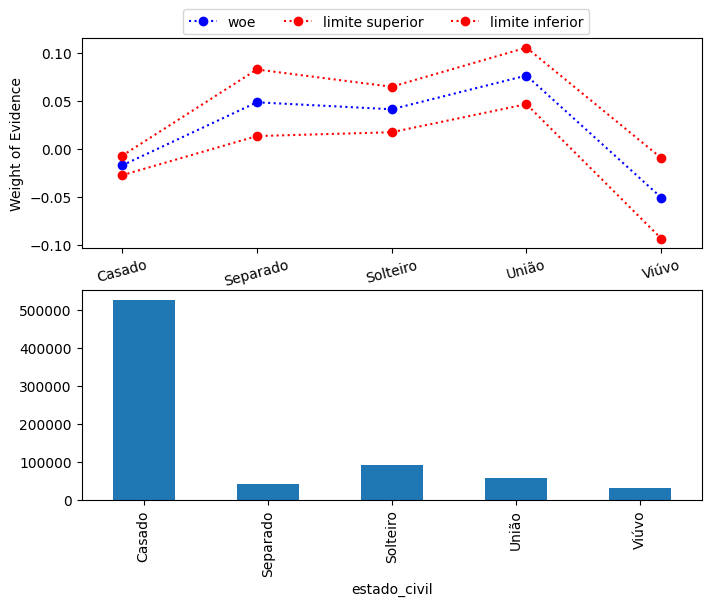

In [21]:
biv_discreta('estado_civil', df);

,qt_bom,qt_mau,mau,tipo_renda,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
tipo_renda,,,,,,,,,,,,,,
Assalariado,354527,31213,0.080917,Assalariado,385740,0.000439,0.081778,0.080057,-2.429950,-2.418434,-2.441578,0.037238,0.048754,0.025610
Bolsista,346,15,0.041551,Bolsista,361,0.010503,0.062207,0.020896,-3.138389,-2.713068,-3.847087,-0.671200,-0.245880,-1.379899
Empresário,159508,13204,0.076451,Empresário,172712,0.000639,0.077704,0.075198,-2.491574,-2.473957,-2.509458,-0.024386,-0.006769,-0.042270
Pensionista,115825,10440,0.082683,Pensionista,126265,0.000775,0.084202,0.081164,-2.406436,-2.386573,-2.426634,0.060752,0.080615,0.040555
Servidor público,61151,3771,0.058085,Servidor público,64922,0.000918,0.059884,0.056286,-2.786006,-2.753587,-2.819381,-0.318818,-0.286399,-0.352193


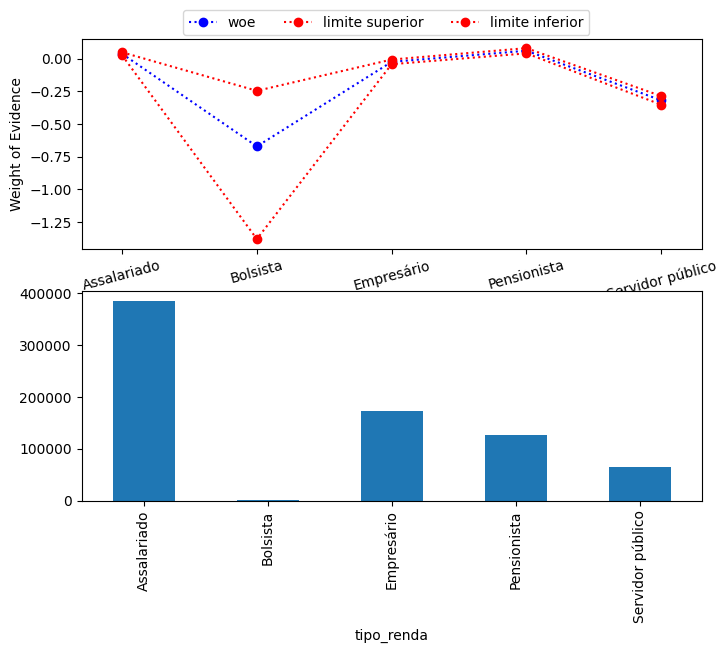

In [22]:
biv_discreta('tipo_renda', df)

,qt_bom,qt_mau,mau,tipo_renda,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
tipo_renda,,,,,,,,,,,,,,
Assalariado,354527,31213,0.080917,Assalariado,385740,0.000439,0.081778,0.080057,-2.429950,-2.418434,-2.441578,0.037238,0.048754,0.025610
Bolsista,346,15,0.041551,Bolsista,361,0.010503,0.062207,0.020896,-3.138389,-2.713068,-3.847087,-0.671200,-0.245880,-1.379899
Empresário,159508,13204,0.076451,Empresário,172712,0.000639,0.077704,0.075198,-2.491574,-2.473957,-2.509458,-0.024386,-0.006769,-0.042270
Pensionista,115825,10440,0.082683,Pensionista,126265,0.000775,0.084202,0.081164,-2.406436,-2.386573,-2.426634,0.060752,0.080615,0.040555
Servidor público,61151,3771,0.058085,Servidor público,64922,0.000918,0.059884,0.056286,-2.786006,-2.753587,-2.819381,-0.318818,-0.286399,-0.352193


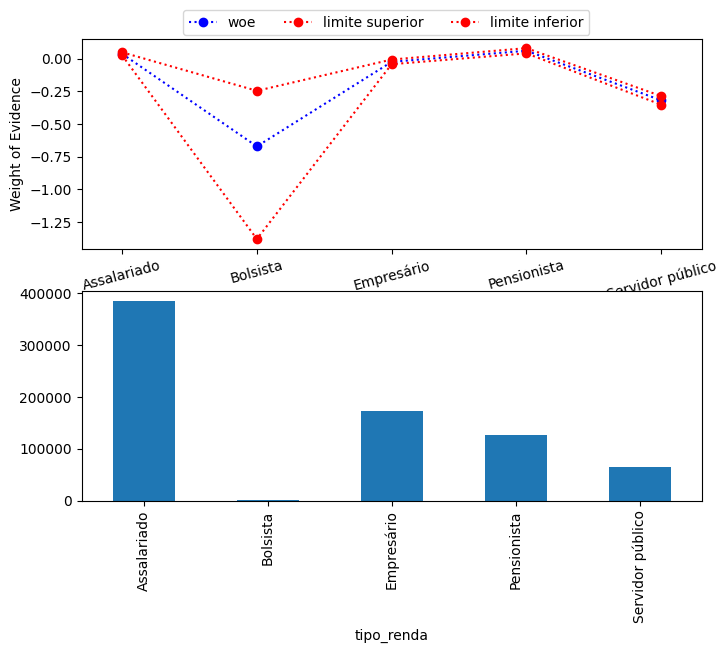

In [23]:
df2 = df.copy()
df2.tipo_renda.replace({'Student': 'St. ser./Stud.', 'State servant': 'St. ser./Stud.'}, inplace=True)
biv_discreta('tipo_renda', df2)

In [24]:
IV(df2.tipo_renda, df.mau)

0.009360061148107996

,qt_bom,qt_mau,mau,educacao,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
educacao,,,,,,,,,,,,,,
Fundamental,7789,786,0.091662,Fundamental,8575,0.003116,0.097770,0.085554,-2.293511,-2.222252,-2.369175,0.173677,0.244936,0.098013
Médio,466106,40730,0.080361,Médio,506836,0.000382,0.081110,0.079613,-2.437448,-2.427364,-2.447619,0.029740,0.039824,0.019570
Pós graduação,753,59,0.072660,Pós graduação,812,0.009109,0.090541,0.054779,-2.546528,-2.307049,-2.848105,-0.079340,0.160139,-0.380917
Superior completo,189684,14622,0.071569,Superior completo,204306,0.000570,0.072687,0.070451,-2.562832,-2.546130,-2.579777,-0.095644,-0.078942,-0.112588
Superior incompleto,27025,2446,0.082997,Superior incompleto,29471,0.001607,0.086147,0.079847,-2.402308,-2.361619,-2.444427,0.064880,0.105569,0.022761


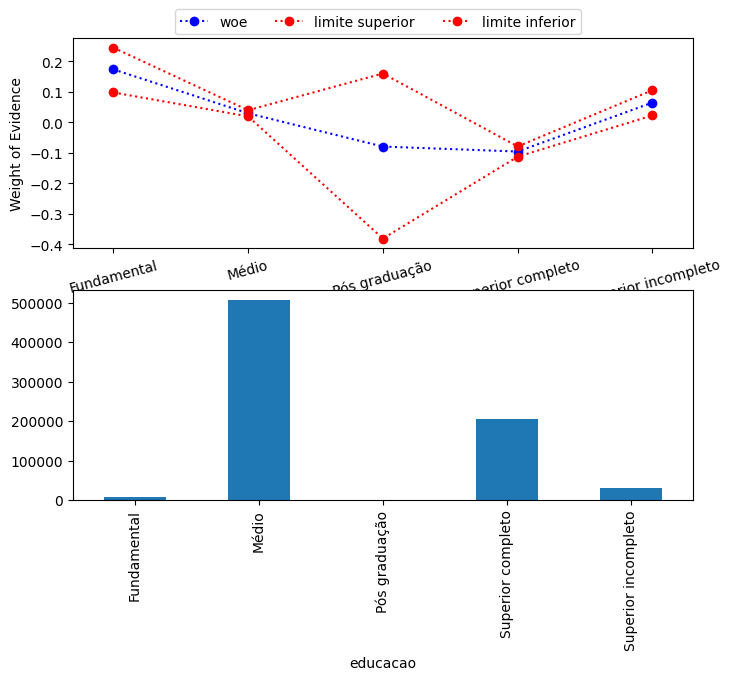

In [25]:
biv_discreta('educacao', df2)

,qt_bom,qt_mau,mau,educacao,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
educacao,,,,,,,,,,,,,,
Fundamental,7789,786,0.091662,Fundamental,8575,0.003116,0.097770,0.085554,-2.293511,-2.222252,-2.369175,0.173677,0.244936,0.098013
Médio,466106,40730,0.080361,Médio,506836,0.000382,0.081110,0.079613,-2.437448,-2.427364,-2.447619,0.029740,0.039824,0.019570
Pós graduação,753,59,0.072660,Pós graduação,812,0.009109,0.090541,0.054779,-2.546528,-2.307049,-2.848105,-0.079340,0.160139,-0.380917
Superior completo,189684,14622,0.071569,Superior completo,204306,0.000570,0.072687,0.070451,-2.562832,-2.546130,-2.579777,-0.095644,-0.078942,-0.112588
Superior incompleto,27025,2446,0.082997,Superior incompleto,29471,0.001607,0.086147,0.079847,-2.402308,-2.361619,-2.444427,0.064880,0.105569,0.022761


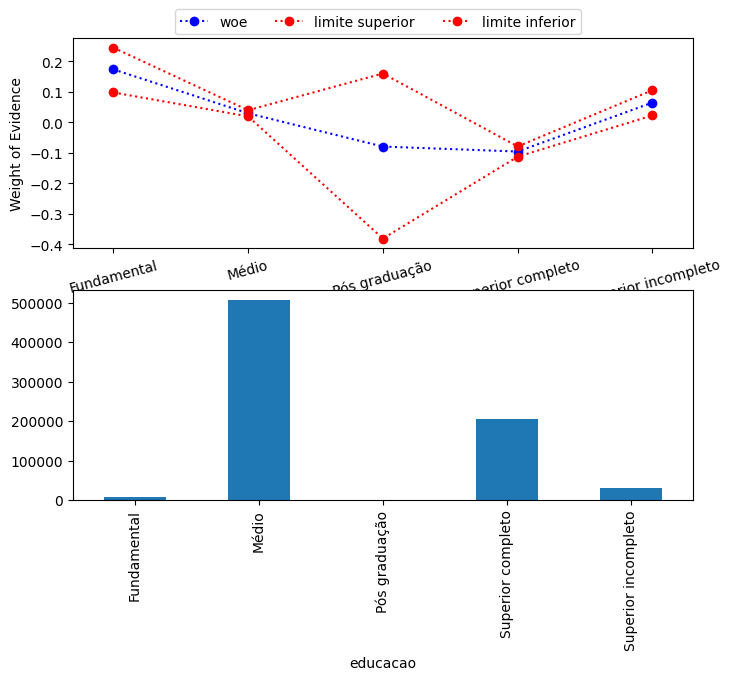

In [26]:
df2.educacao.replace({'Academic degree':'Academic/Higher', 'Higher education': 'Academic/Higher'}, inplace=True)
biv_discreta('educacao', df2)

0.0035465188386237987

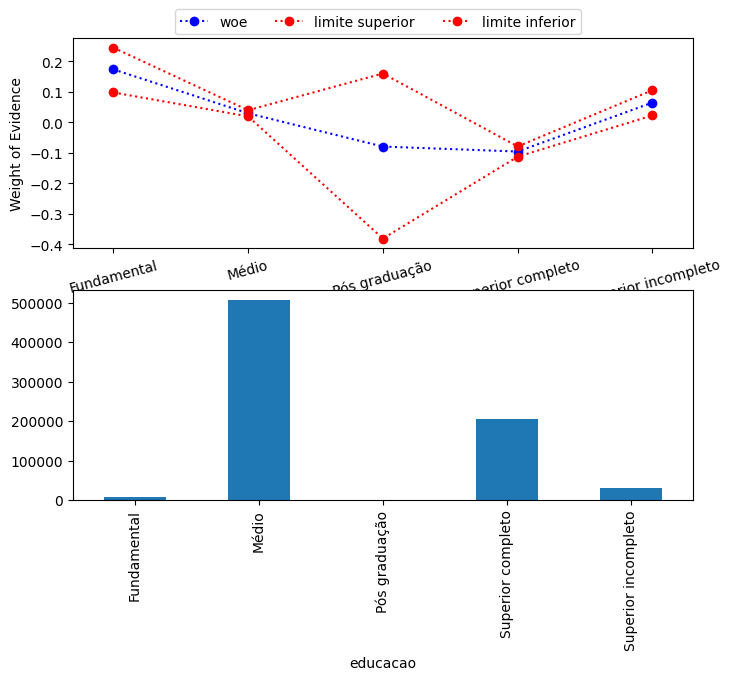

In [27]:
df2.educacao.replace({'Incomplete higher':'Academic/Higher',
                      'Lower secondary':'lower/Secondary',
                      'Secondary / secondary special': 'lower/Secondary'
                     }, inplace=True)
biv_discreta('educacao', df2)
IV(df2.educacao, df.mau)

In [28]:
def biv_continua(var, ncat, df):
    df['bom'] = 1-df.mau
    cat_srs, bins = pd.qcut(df[var], ncat, retbins=True, precision=0, duplicates='drop')
    g = df.groupby(cat_srs)

    biv = pd.DataFrame({'qt_bom': g['bom'].sum(),
                        'qt_mau': g['mau'].sum(),
                        'mau':g['mau'].mean(),
                        var: g[var].mean(),
                        'cont':g[var].count()})

    biv['ep'] = (biv.mau*(1-biv.mau)/biv.cont)**.5
    biv['mau_sup'] = biv.mau+t.ppf([0.975], biv.cont-1)*biv.ep
    biv['mau_inf'] = biv.mau+t.ppf([0.025], biv.cont-1)*biv.ep

    biv['logit'] = np.log(biv.mau/(1-biv.mau))
    biv['logit_sup'] = np.log(biv.mau_sup/(1-biv.mau_sup))
    biv['logit_inf'] = np.log(biv.mau_inf/(1-biv.mau_inf))

    tx_mau_geral = df.mau.mean()
    woe_geral = np.log(df.mau.mean() / (1 - df.mau.mean()))

    biv['woe'] = biv.logit - woe_geral
    biv['woe_sup'] = biv.logit_sup - woe_geral
    biv['woe_inf'] = biv.logit_inf - woe_geral

    fig, ax = plt.subplots(2,1, figsize=(8,6))
    ax[0].plot(biv[var], biv.woe, ':bo', label='woe')
    ax[0].plot(biv[var], biv.woe_sup, 'o:r', label='limite superior')
    ax[0].plot(biv[var], biv.woe_inf, 'o:r', label='limite inferior')

    num_cat = biv.shape[0]

    ax[0].set_ylabel("Weight of Evidence")
    ax[0].legend(bbox_to_anchor=(.83, 1.17), ncol=3)

    ax[1] = biv.cont.plot.bar()
    return None

/tmp/ipykernel_25073/1184019071.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(cat_srs)


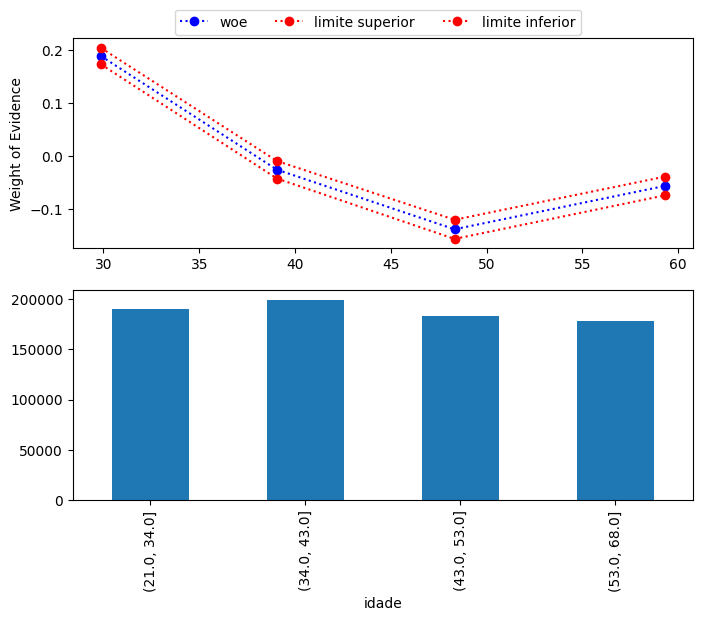

In [29]:
biv_continua('idade', 4, df)

In [30]:
df.columns
df.tempo_emprego.describe()

count    624043.000000
mean          7.748574
std           6.687455
min           0.117808
25%           3.049315
50%           6.046575
75%          10.183562
max          42.906849
Name: tempo_emprego, dtype: float64

/tmp/ipykernel_25073/1184019071.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(cat_srs)


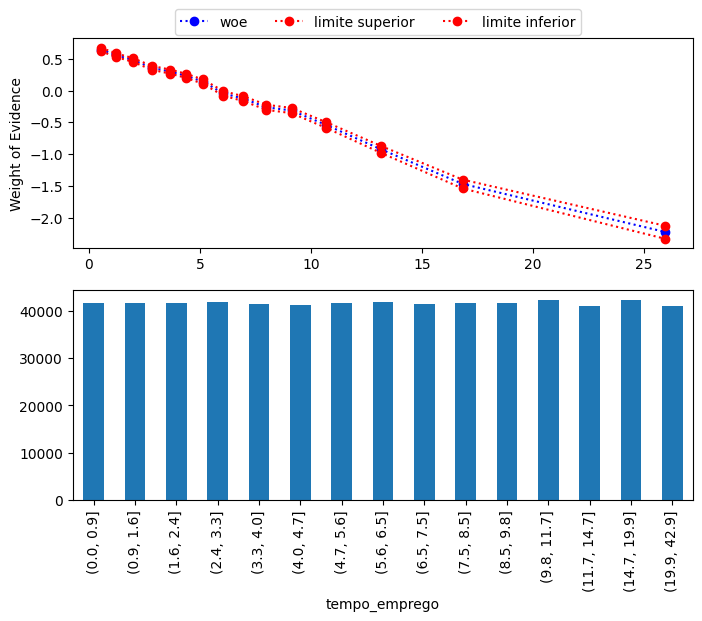

In [31]:
df2.loc[df2['tempo_emprego']<0,'tempo_emprego'] = -1
biv_continua('tempo_emprego', 15, df2)

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [32]:
# ajuda para definir a equação da regressão
' + '.join(list(df.columns))

'data_ref + index + sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + tipo_renda + educacao + estado_civil + tipo_residencia + idade + tempo_emprego + qt_pessoas_residencia + renda + mau + bom'

,qt_bom,qt_mau,mau,educacao,cont,ep,mau_sup,mau_inf,logit,logit_sup,logit_inf,woe,woe_sup,woe_inf
educacao,,,,,,,,,,,,,,
Fundamental,7789,786,0.091662,Fundamental,8575,0.003116,0.097770,0.085554,-2.293511,-2.222252,-2.369175,0.173677,0.244936,0.098013
Médio,466106,40730,0.080361,Médio,506836,0.000382,0.081110,0.079613,-2.437448,-2.427364,-2.447619,0.029740,0.039824,0.019570
Pós graduação,753,59,0.072660,Pós graduação,812,0.009109,0.090541,0.054779,-2.546528,-2.307049,-2.848105,-0.079340,0.160139,-0.380917
Superior completo,189684,14622,0.071569,Superior completo,204306,0.000570,0.072687,0.070451,-2.562832,-2.546130,-2.579777,-0.095644,-0.078942,-0.112588
Superior incompleto,27025,2446,0.082997,Superior incompleto,29471,0.001607,0.086147,0.079847,-2.402308,-2.361619,-2.444427,0.064880,0.105569,0.022761


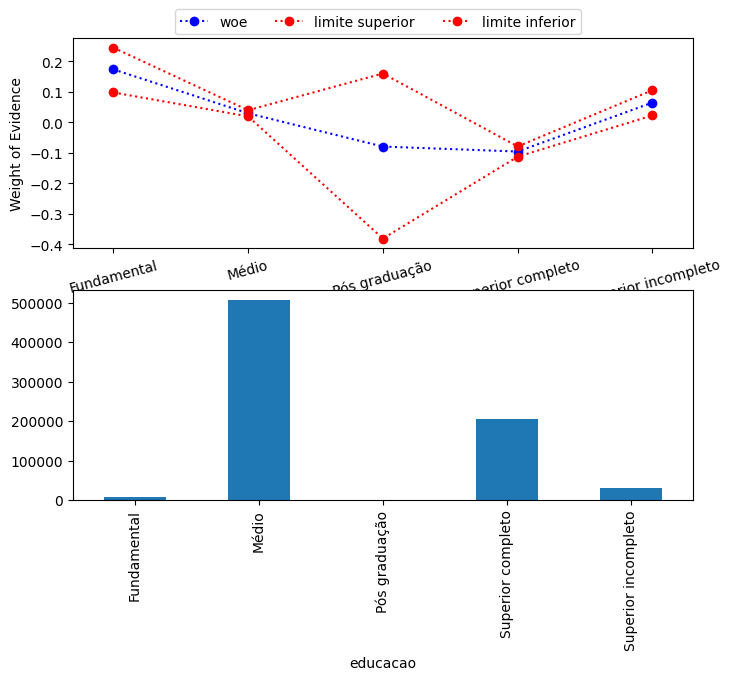

In [33]:
biv_discreta('educacao', df2)

In [34]:
df.columns

Index(['data_ref', 'index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel',
       'qtd_filhos', 'tipo_renda', 'educacao', 'estado_civil',
       'tipo_residencia', 'idade', 'tempo_emprego', 'qt_pessoas_residencia',
       'renda', 'mau', 'bom'],
      dtype='object')

In [35]:
formula = '''
    mau ~ sexo + posse_de_veiculo + posse_de_imovel + qtd_filhos + tipo_renda +
    educacao + estado_civil + tipo_residencia + idade + tempo_emprego +
    qt_pessoas_residencia + renda
'''

rl = smf.glm(formula, data=df2, family=sm.families.Binomial()).fit()

rl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Generalized Linear Model Regression Results                      
=======================================================================================
Dep. Variable:     ['mau[False]', 'mau[True]']   No. Observations:               624043
Model:                                     GLM   Df Residuals:                   624017
Model Family:                         Binomial   Df Model:                           25
Link Function:                           Logit   Scale:                          1.0000
Method:                                   IRLS   Log-Likelihood:            -1.5058e+05
Date:                         Fri, 25 Apr 2025   Deviance:                   3.0116e+05
Time:                                 11:34:40   Pearson chi2:                 4.09e+16
No. Iterations:                             11   Pseudo R-squ. (CS):            0.05978
Covariance Type:                     nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            1.0117      0.169      5.998      0.000       0.681       1.342
sexo[T.M]                            0.1366      0.011     12.377      0.000       0.115       0.158
posse_de_veiculo[T.S]               -0.0230      0.011     -2.155      0.031      -0.044      -0.002
posse_de_imovel[T.S]                 0.1031      0.010      9.988      0.000       0.083       0.123
tipo_renda[T.Bolsista]               0.1461      0.268      0.544      0.586      -0.380       0.672
tipo_renda[T.Empresário]             0.0515      0.011      4.580      0.000       0.029       0.074
tipo_renda[T.Pensionista]           -0.0636      0.186     -0.343      0.732      -0.427       0.300
tipo_renda[T.Servidor público]       0.0290      0.019      1.560      0.119      -0.007       0.065
educacao[T.Médio]                    0.0644      0.051      1.264      0.206      -0.035       0.164
educacao[T.Pós graduação]            0.2624      0.147      1.786      0.074      -0.026       0.550
educacao[T.Superior completo]        0.1326      0.052      2.573      0.010       0.032       0.234
educacao[T.Superior incompleto]      0.1077      0.055      1.949      0.051      -0.001       0.216
estado_civil[T.Separado]             0.0032      0.080      0.040      0.968      -0.154       0.161
estado_civil[T.Solteiro]             0.0110      0.079      0.140      0.889      -0.143       0.165
estado_civil[T.União]               -0.0151      0.018     -0.848      0.397      -0.050       0.020
estado_civil[T.Viúvo]                0.1521      0.086      1.778      0.075      -0.016       0.320
tipo_residencia[T.Casa]              0.0623      0.037      1.702      0.089      -0.009       0.134
tipo_residencia[T.Com os pais]       0.0574      0.041      1.401      0.161      -0.023       0.138
tipo_residencia[T.Comunitário]       0.1727      0.074      2.334      0.020       0.028       0.318
tipo_residencia[T.Estúdio]           0.0379      0.070      0.539      0.590      -0.100       0.175
tipo_residencia[T.Governamental]     0.0574      0.045      1.267      0.205      -0.031       0.146
qtd_filhos                          -0.0212      0.078     -0.273      0.785      -0.173       0.131
idade                                0.0003      0.001      0.556      0.578      -0.001       0.001
tempo_emprego                        0.0290      0.001     20.523      0.000       0.026       0.032
qt_pessoas_residencia                0.0218      0.078      0.281      0.779      -0.130       0.174
renda                                0.0001   1.14e-06    107.676      0.000       0.000       0.000
=======================================================

In [36]:
metadados.sort_values(by='IV', ascending=False)

,dtype,nmissing,valores_unicos,papel,IV
renda,float64,0.0,142419.0,covariavel,1.068628
tempo_emprego,float64,125957.0,3004.0,covariavel,0.351920
data_ref,datetime64[ns],0.0,15.0,covariavel,0.345982
idade,int64,0.0,47.0,covariavel,0.017968
posse_de_imovel,object,0.0,2.0,covariavel,0.009693
tipo_renda,object,0.0,5.0,covariavel,0.009360
educacao,object,0.0,5.0,covariavel,0.003547
tipo_residencia,object,0.0,6.0,covariavel,0.003045
index,int64,0.0,16650.0,covariavel,0.002664
sexo,object,0.0,2.0,covariavel,0.002185


In [37]:
' + '.join(list(metadados.sort_values(by='IV', ascending=False).index))

'renda + tempo_emprego + data_ref + idade + posse_de_imovel + tipo_renda + educacao + tipo_residencia + index + sexo + qt_pessoas_residencia + estado_civil + posse_de_veiculo + qtd_filhos + mau + bom'

In [38]:
formula = '''
    mau ~ tempo_emprego + estado_civil
    + idade + posse_de_imovel + tipo_renda
    + qt_pessoas_residencia + educacao
'''

rl = smf.glm(formula, data=df2, family=sm.families.Binomial()).fit()

rl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Generalized Linear Model Regression Results                      
=======================================================================================
Dep. Variable:     ['mau[False]', 'mau[True]']   No. Observations:               624043
Model:                                     GLM   Df Residuals:                   624026
Model Family:                         Binomial   Df Model:                           16
Link Function:                           Logit   Scale:                          1.0000
Method:                                   IRLS   Log-Likelihood:            -1.6191e+05
Date:                         Fri, 25 Apr 2025   Deviance:                   3.2381e+05
Time:                                 11:34:45   Pearson chi2:                 6.23e+05
No. Iterations:                              7   Pseudo R-squ. (CS):            0.02502
Covariance Type:                     nonrobust                                         
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           1.3949      0.058     24.107      0.000       1.282       1.508
estado_civil[T.Separado]           -0.0555      0.022     -2.558      0.011      -0.098      -0.013
estado_civil[T.Solteiro]           -0.0150      0.017     -0.868      0.385      -0.049       0.019
estado_civil[T.União]              -0.0265      0.017     -1.518      0.129      -0.061       0.008
estado_civil[T.Viúvo]               0.0882      0.036      2.432      0.015       0.017       0.159
posse_de_imovel[T.S]                0.2124      0.010     21.416      0.000       0.193       0.232
tipo_renda[T.Bolsista]             -0.0831      0.264     -0.315      0.753      -0.601       0.435
tipo_renda[T.Empresário]            0.1222      0.011     11.075      0.000       0.101       0.144
tipo_renda[T.Pensionista]          -0.3820      0.184     -2.074      0.038      -0.743      -0.021
tipo_renda[T.Servidor público]      0.0763      0.018      4.182      0.000       0.041       0.112
educacao[T.Médio]                   0.0385      0.050      0.772      0.440      -0.059       0.136
educacao[T.Pós graduação]           0.3261      0.145      2.254      0.024       0.043       0.610
educacao[T.Superior completo]       0.1795      0.050      3.557      0.000       0.081       0.278
educacao[T.Superior incompleto]     0.1351      0.054      2.493      0.013       0.029       0.241
tempo_emprego                       0.1220      0.001    100.357      0.000       0.120       0.124
idade                               0.0029      0.001      5.064      0.000       0.002       0.004
qt_pessoas_residencia              -0.0089      0.006     -1.389      0.165      -0.021       0.004
===================================================================================================
"""

In [39]:
formula = '''
    mau ~ tempo_emprego + estado_civil
    + idade + posse_de_imovel
    + qt_pessoas_residencia
'''

rl = smf.glm(formula, data=df2, family=sm.families.Binomial()).fit()

rl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Generalized Linear Model Regression Results                      
=======================================================================================
Dep. Variable:     ['mau[False]', 'mau[True]']   No. Observations:               624043
Model:                                     GLM   Df Residuals:                   624034
Model Family:                         Binomial   Df Model:                            8
Link Function:                           Logit   Scale:                          1.0000
Method:                                   IRLS   Log-Likelihood:            -1.6208e+05
Date:                         Fri, 25 Apr 2025   Deviance:                   3.2416e+05
Time:                                 11:34:50   Pearson chi2:                 6.23e+05
No. Iterations:                              7   Pseudo R-squ. (CS):            0.02447
Covariance Type:                     nonrobust                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    1.5754      0.031     50.207      0.000       1.514       1.637
estado_civil[T.Separado]    -0.0568      0.022     -2.617      0.009      -0.099      -0.014
estado_civil[T.Solteiro]    -0.0083      0.017     -0.480      0.631      -0.042       0.026
estado_civil[T.União]       -0.0259      0.017     -1.484      0.138      -0.060       0.008
estado_civil[T.Viúvo]        0.0724      0.036      2.001      0.045       0.001       0.143
posse_de_imovel[T.S]         0.2181      0.010     22.036      0.000       0.199       0.237
tempo_emprego                0.1221      0.001    101.055      0.000       0.120       0.124
idade                        0.0015      0.001      2.772      0.006       0.000       0.003
qt_pessoas_residencia       -0.0122      0.006     -1.899      0.058      -0.025       0.000
============================================================================================
"""

In [40]:
df2['score'] = rl.predict(df2)

# Acurácia
acc = metrics.accuracy_score(df2.mau, df2.score>.068)
#
# Remove rows with NaN values before calculating metrics
df2_clean = df2.dropna(subset=['mau', 'score'])
fpr, tpr, thresholds = metrics.roc_curve(df2_clean.mau, df2_clean.score)

auc = metrics.auc(fpr, tpr)
#Gini
gini = 2*auc -1
ks = ks_2samp(df2.loc[df2.mau == 1, 'score'], df2.loc[df2.mau != 1, 'score']).statistic

print('Acurácia: {0:.1%} \nAUC: {1:.1%} \nGINI: {2:.1%}\nKS: {3:.1%}'
      .format(acc, auc, gini, ks))

Acurácia: 21.8% 
AUC: 34.1% 
GINI: -31.8%
KS: 18.6%


## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

In [41]:
# Separar dados de desenvolvimento e out-of-time
datas = pd.to_datetime(df2.data_ref).sort_values().unique()
data_corte = datas[-3]  # 3 últimos meses para OOT

df_dev = df2[pd.to_datetime(df2.data_ref) < data_corte].copy()
df_oot = df2[pd.to_datetime(df2.data_ref) >= data_corte].copy()

# Calcular scores para ambas as bases
df_dev['score'] = rl.predict(df_dev)
df_oot['score'] = rl.predict(df_oot)


# Função para calcular métricas
def calc_metricas(df, nome):
    acc = metrics.accuracy_score(df.mau, df.score > 0.068)

    # Remove rows with NaN values
    df_clean = df.dropna(subset=['mau', 'score'])
    fpr, tpr, _ = metrics.roc_curve(df_clean.mau, df_clean.score)

    auc = metrics.auc(fpr, tpr)
    gini = 2 * auc - 1
    ks = ks_2samp(df.loc[df.mau == 1, 'score'],
                  df.loc[df.mau != 1, 'score']).statistic

    print(f"\nMétricas para {nome}:")
    print(f"Acurácia: {acc:.1%}")
    print(f"AUC: {auc:.1%}")
    print(f"GINI: {gini:.1%}")
    print(f"KS: {ks:.1%}")

In [42]:
# Calcular métricas para desenvolvimento e OOT
calc_metricas(df_dev, "Base de Desenvolvimento")
calc_metricas(df_oot, "Base Out-of-Time")


Métricas para Base de Desenvolvimento:
Acurácia: 20.8%
AUC: 34.0%
GINI: -32.1%
KS: 18.9%

Métricas para Base Out-of-Time:
Acurácia: 26.2%
AUC: 33.6%
GINI: -32.8%
KS: 19.0%


## Criar um pipeline utilizando o sklearn pipeline 

In [43]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


X_digits, y_digits = load_digits(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.3, random_state=10)

pca = PCA(n_components=20)

scaler = StandardScaler()

logistic = LogisticRegression(max_iter=200)

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [44]:
X_digits.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [45]:
# Suponha que 'X_digits' seja um array NumPy
X_digits.shape

# 'shape' agora contém uma tupla com o número de linhas e colunas
# Por exemplo, se 'X_digits' tiver 100 linhas e 20 colunas, shape será (100, 20)

(1797, 64)

In [46]:
X_train.shape

(1257, 64)

In [47]:
# "Fitando" e aplicando Z score nos dados de treino
scaler.fit(X_train)
X_train = scaler.transform(X_train)

 Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [48]:
pca.fit(X_train)
X_train =  pca.transform(X_train)

In [49]:
# "Fitando" e predizendo uma regressão logística nos dados de treino
logistic.fit(X_train, y_train)

logistic.predict(X_train)

array([0, 0, 0, ..., 2, 1, 2])

In [50]:
# Aplicando nos dados de teste o Z score "fitado" nos dados de treino
X_test = scaler.transform(X_test)

In [51]:
# Aplicando nos dados de teste o PCA "fitado" nos dados de treino
X_test = pca.transform(X_test)

In [52]:
# Predizendo nos dados de teste o modelo "fitado" nos dados de treino
logistic.predict(X_test)

array([5, 2, 5, 4, 8, 3, 4, 3, 3, 0, 8, 7, 0, 1, 8, 6, 9, 7, 9, 7, 1, 6,
       6, 7, 8, 8, 5, 8, 9, 9, 3, 3, 7, 3, 4, 1, 9, 2, 5, 4, 2, 1, 0, 1,
       2, 2, 6, 1, 9, 4, 4, 5, 8, 4, 8, 5, 9, 7, 8, 0, 4, 5, 8, 4, 7, 9,
       0, 7, 1, 3, 9, 3, 3, 8, 0, 7, 3, 6, 5, 2, 0, 8, 8, 0, 1, 2, 2, 8,
       8, 8, 2, 6, 3, 4, 7, 9, 8, 2, 9, 2, 5, 0, 8, 0, 4, 8, 8, 0, 6, 7,
       3, 3, 9, 1, 2, 4, 6, 0, 8, 8, 1, 1, 7, 3, 9, 5, 2, 3, 3, 9, 7, 6,
       2, 5, 4, 3, 8, 7, 6, 7, 2, 7, 4, 9, 5, 1, 9, 8, 6, 1, 8, 1, 4, 0,
       9, 9, 1, 2, 3, 5, 0, 3, 4, 1, 5, 4, 9, 3, 5, 6, 4, 0, 8, 6, 7, 0,
       9, 9, 4, 7, 5, 5, 2, 0, 6, 7, 5, 3, 9, 7, 1, 3, 2, 8, 3, 3, 1, 7,
       1, 1, 1, 7, 1, 6, 7, 6, 9, 5, 2, 3, 5, 2, 9, 5, 4, 8, 2, 9, 1, 5,
       4, 2, 3, 9, 0, 2, 0, 2, 1, 0, 5, 0, 6, 4, 2, 1, 9, 0, 9, 0, 6, 9,
       4, 4, 9, 7, 5, 6, 1, 5, 7, 0, 8, 6, 2, 5, 1, 2, 3, 8, 4, 4, 3, 5,
       7, 9, 7, 2, 0, 2, 0, 9, 2, 8, 6, 3, 1, 0, 6, 6, 6, 7, 1, 6, 1, 7,
       6, 0, 6, 3, 7, 4, 6, 2, 2, 0, 8, 4, 7, 3, 3,

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.3, random_state=10)

# Define a PCA to Linear dimensionality reduction
pca_pipe = PCA(n_components=15)

# Define a Standard Scaler to normalize inputs
scaler_pipe = StandardScaler()

# set the tolerance to a large value to make the example faster
logistic_pipe = LogisticRegression(max_iter=200)

In [54]:
pipe = Pipeline(steps=[("scaler", scaler_pipe),
                       ("pca", pca_pipe),
                       ("logistic", logistic_pipe)])

In [55]:
pipe.named_steps

{'scaler': StandardScaler(),
 'pca': PCA(n_components=15),
 'logistic': LogisticRegression(max_iter=200)}

In [56]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=15)),
                ('logistic', LogisticRegression(max_iter=200))])

In [57]:
pipe.predict(X_train)

array([0, 0, 0, ..., 1, 8, 2])

In [58]:
pipe.predict(X_test)

array([5, 2, 5, 4, 8, 1, 4, 3, 3, 0, 8, 7, 0, 1, 8, 6, 9, 7, 9, 7, 1, 6,
       6, 7, 8, 8, 5, 8, 9, 9, 3, 3, 7, 3, 4, 1, 9, 2, 5, 4, 2, 1, 0, 1,
       2, 3, 6, 1, 9, 4, 4, 9, 8, 4, 8, 5, 9, 7, 1, 0, 4, 5, 8, 4, 7, 9,
       0, 7, 1, 3, 3, 3, 3, 8, 0, 7, 3, 6, 5, 2, 0, 8, 8, 0, 1, 2, 2, 8,
       8, 8, 2, 6, 3, 4, 7, 9, 8, 2, 9, 2, 5, 0, 8, 0, 4, 8, 8, 0, 6, 7,
       3, 3, 9, 1, 2, 4, 6, 0, 8, 8, 1, 1, 7, 8, 9, 5, 2, 3, 3, 9, 7, 6,
       2, 5, 4, 3, 8, 4, 6, 7, 2, 7, 4, 9, 5, 1, 9, 8, 6, 1, 8, 1, 4, 0,
       9, 9, 1, 2, 3, 5, 0, 3, 4, 1, 5, 4, 9, 3, 5, 6, 4, 0, 8, 6, 7, 0,
       9, 9, 4, 7, 9, 5, 2, 0, 6, 7, 5, 3, 9, 7, 1, 3, 2, 8, 8, 3, 1, 7,
       1, 1, 1, 7, 1, 6, 7, 6, 9, 5, 2, 3, 5, 2, 9, 5, 4, 8, 2, 0, 1, 5,
       4, 2, 3, 9, 0, 2, 0, 2, 1, 0, 5, 0, 6, 4, 2, 1, 9, 0, 9, 0, 6, 9,
       4, 4, 9, 7, 5, 6, 1, 8, 7, 0, 8, 6, 2, 5, 1, 2, 3, 8, 4, 4, 3, 5,
       7, 9, 7, 2, 0, 2, 0, 9, 2, 8, 6, 3, 1, 0, 6, 6, 6, 7, 1, 6, 1, 7,
       6, 0, 6, 3, 7, 4, 6, 2, 2, 0, 8, 4, 7, 3, 3,

In [59]:
pipe.named_steps

{'scaler': StandardScaler(),
 'pca': PCA(n_components=15),
 'logistic': LogisticRegression(max_iter=200)}

In [60]:
pipe.steps

[('scaler', StandardScaler()),
 ('pca', PCA(n_components=15)),
 ('logistic', LogisticRegression(max_iter=200))]

In [61]:
pipe[0]

StandardScaler()

In [62]:
pipe[1]

PCA(n_components=15)

In [63]:
pipe[2]

LogisticRegression(max_iter=200)

In [64]:
pipe[1].transform(X_train)

/home/fabio/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


array([[  0.87096812, -12.61621898, -18.95613561, ...,   5.50340118,
         15.94500435,   3.82096016],
       [  7.38999882,  -7.84625319, -16.49051379, ...,   8.86590792,
         19.89279438,   2.63040936],
       [  8.28997345, -10.02860967, -14.17130527, ...,   9.56571228,
         27.22019027,   3.93560072],
       ...,
       [-12.90641356, -12.77045057,  16.6917044 , ...,   1.9369928 ,
         10.3115821 ,   6.72547484],
       [-12.20196543,  -2.58782318,   7.00779308, ...,   9.13928616,
          9.79915682,   2.53087018],
       [-11.21464309,   2.61289602,   2.68294708, ...,   4.50650621,
         18.58995554,  -4.87967024]])

In [65]:
pca_pipe.transform(X_train)

/home/fabio/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


array([[  0.87096812, -12.61621898, -18.95613561, ...,   5.50340118,
         15.94500435,   3.82096016],
       [  7.38999882,  -7.84625319, -16.49051379, ...,   8.86590792,
         19.89279438,   2.63040936],
       [  8.28997345, -10.02860967, -14.17130527, ...,   9.56571228,
         27.22019027,   3.93560072],
       ...,
       [-12.90641356, -12.77045057,  16.6917044 , ...,   1.9369928 ,
         10.3115821 ,   6.72547484],
       [-12.20196543,  -2.58782318,   7.00779308, ...,   9.13928616,
          9.79915682,   2.53087018],
       [-11.21464309,   2.61289602,   2.68294708, ...,   4.50650621,
         18.58995554,  -4.87967024]])

### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

In [66]:
def identify_outliers_zscore(df, column, threshold=3):
    z_scores = (df[column] - df[column].mean()) / df[column].std()
    return abs(z_scores) > threshold

In [67]:
# 2. Método IQR (Interquartile Range) para identificar outliers
def identify_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)


# Exemplo de uso com variáveis numéricas
numeric_cols = ['idade', 'tempo_emprego', 'renda', 'qt_pessoas_residencia']

for col in numeric_cols:
    # Usando Z-score
    outliers_zscore = df[identify_outliers_zscore(df, col)]

    # Usando IQR
    outliers_iqr = df[identify_outliers_iqr(df, col)]

    print(f"\nVariável: {col}")
    print(f"Número de outliers (Z-score): {len(outliers_zscore)}")
    print(f"Número de outliers (IQR): {len(outliers_iqr)}")

    # Tratamento dos outliers - exemplo com winsorization
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)


Variável: idade
Número de outliers (Z-score): 0
Número de outliers (IQR): 0

Variável: tempo_emprego
Número de outliers (Z-score): 11655
Número de outliers (IQR): 34561

Variável: renda
Número de outliers (Z-score): 8583
Número de outliers (IQR): 79072

Variável: qt_pessoas_residencia
Número de outliers (Z-score): 9629
Número de outliers (IQR): 9629


### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

In [68]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Preparar dados para seleção de variáveis
numeric_cols = ['idade', 'tempo_emprego', 'renda', 'qt_pessoas_residencia']
categorical_cols = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda',
                    'educacao', 'estado_civil', 'tipo_residencia']

In [69]:
# Criar dataframe apenas com variáveis numéricas e dummies
X = pd.concat([df[numeric_cols], pd.get_dummies(df[categorical_cols])], axis=1)
y = df['mau']

In [70]:
# Treinar Random Forest para feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [71]:
# Obter importâncias das features
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})
importances = importances.sort_values('importance', ascending=False)

In [72]:
# Selecionar features mais importantes usando SelectFromModel
selector = SelectFromModel(rf, prefit=True)

In [73]:
# Mostrar features selecionadas
selected_features = X.columns[selector.get_support()].tolist()
print("Features selecionadas:", selected_features)

Features selecionadas: ['idade', 'tempo_emprego', 'renda']


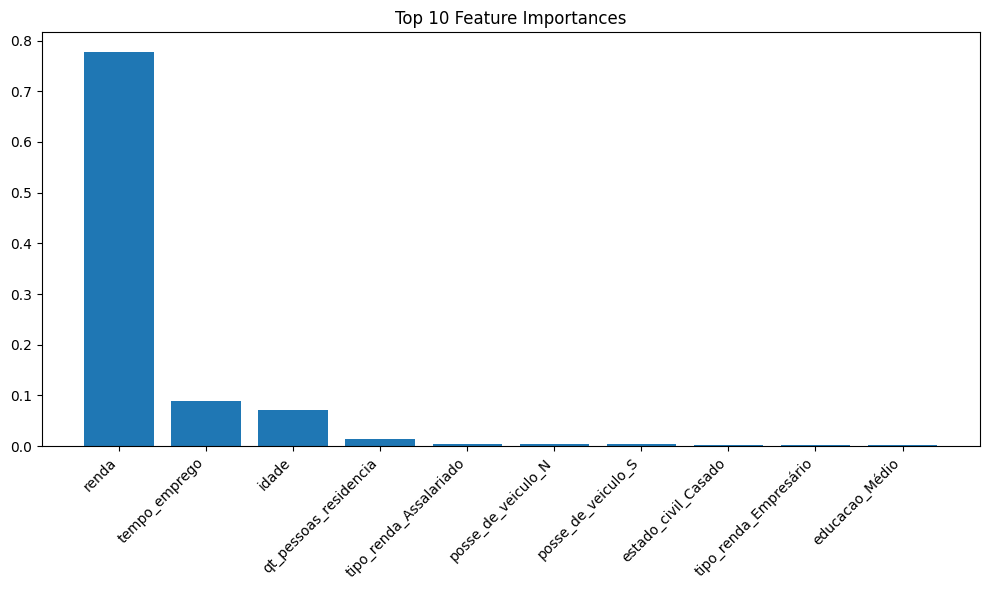

In [74]:
# Plot das importâncias
plt.figure(figsize=(10, 6))
plt.bar(importances['feature'][:10], importances['importance'][:10])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Feature Importances')
plt.tight_layout()

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [75]:
# Applying PCA with 5 components
pca = PCA(n_components=5)
pca.fit(X_train)
X_train = pca.transform(X_train)

# Show variance ratio explained by components
explained_var_ratio = pca.explained_variance_ratio_
cumsum_var_ratio = np.cumsum(explained_var_ratio)

print("Explained variance ratio by component:")
for i, ratio in enumerate(explained_var_ratio):
    print(f"Component {i + 1}: {ratio:.3f}")
print(f"\nCumulative variance explained: {cumsum_var_ratio[-1]:.3%}")

Explained variance ratio by component:
Component 1: 0.149
Component 2: 0.135
Component 3: 0.118
Component 4: 0.086
Component 5: 0.059

Cumulative variance explained: 54.557%


### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

In [76]:
# Create dummy variables for categorical columns
categorical_columns = ['sexo', 'posse_de_veiculo', 'posse_de_imovel',
                       'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']


df_dummies = pd.get_dummies(df[categorical_columns], columns=categorical_columns)
df_dummies.head()

,sexo_F,sexo_M,posse_de_veiculo_N,posse_de_veiculo_S,posse_de_imovel_N,posse_de_imovel_S,tipo_renda_Assalariado,tipo_renda_Bolsista,tipo_renda_Empresário,tipo_renda_Pensionista,...,estado_civil_Separado,estado_civil_Solteiro,estado_civil_União,estado_civil_Viúvo,tipo_residencia_Aluguel,tipo_residencia_Casa,tipo_residencia_Com os pais,tipo_residencia_Comunitário,tipo_residencia_Estúdio,tipo_residencia_Governamental
0,True,False,True,False,True,False,False,False,True,False,...,False,True,False,False,False,True,False,False,False,False
1,True,False,False,True,False,True,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,True,False,True,False,True,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,True,False,True,False,True,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,True,False,False,True,True,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,False


### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

In [77]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer



# Custom transformer for outlier handling using IQR
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.Q1 = None
        self.Q3 = None
        self.IQR = None

    def fit(self, X, y=None):
        # Calculate Q1, Q3 and IQR for numerical columns
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        return self

    def transform(self, X):
        # Clip values outside the IQR bounds
        X_copy = X.copy()
        lower_bound = self.Q1 - 1.5 * self.IQR
        upper_bound = self.Q3 + 1.5 * self.IQR
        return X_copy.clip(lower=lower_bound, upper=upper_bound)


# Custom transformer for creating dummy variables
class DummyTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Create dummy for posse_de_veiculo
        dummies = pd.get_dummies(X_copy['posse_de_veiculo'], prefix='posse_de_veiculo')
        X_copy = pd.concat([X_copy, dummies], axis=1)
        X_copy = X_copy.drop('posse_de_veiculo', axis=1)
        return X_copy


# Create preprocessing pipeline
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('outlier_handler', OutlierHandler()),
    ('scaler', StandardScaler()),
    ('dummy', DummyTransformer()),
    ('pca', PCA(n_components=5))
])

### Treinar um modelo de regressão logistica com o resultado

In [78]:
df_dummies.dtypes

sexo_F                           bool
sexo_M                           bool
posse_de_veiculo_N               bool
posse_de_veiculo_S               bool
posse_de_imovel_N                bool
posse_de_imovel_S                bool
tipo_renda_Assalariado           bool
tipo_renda_Bolsista              bool
tipo_renda_Empresário            bool
tipo_renda_Pensionista           bool
tipo_renda_Servidor público      bool
educacao_Fundamental             bool
educacao_Médio                   bool
educacao_Pós graduação           bool
educacao_Superior completo       bool
educacao_Superior incompleto     bool
estado_civil_Casado              bool
estado_civil_Separado            bool
estado_civil_Solteiro            bool
estado_civil_União               bool
estado_civil_Viúvo               bool
tipo_residencia_Aluguel          bool
tipo_residencia_Casa             bool
tipo_residencia_Com os pais      bool
tipo_residencia_Comunitário      bool
tipo_residencia_Estúdio          bool
tipo_residen


b - Pycaret na base de dados

Utilize o pycaret para pre processar os dados e rodar o modelo lightgbm. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.


In [79]:
import pandas as pd
#from pycaret.classification import *
df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [80]:
dataset = df.sample(50000)

In [81]:
df.columns

Index(['data_ref', 'index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel',
       'qtd_filhos', 'tipo_renda', 'educacao', 'estado_civil',
       'tipo_residencia', 'idade', 'tempo_emprego', 'qt_pessoas_residencia',
       'renda', 'mau'],
      dtype='object')

In [82]:
dataset = df.sample(40000)

In [83]:
dataset.drop(['data_ref','index'], axis=1, inplace=True)

In [84]:
data = dataset.sample(frac=0.95, random_state=786)
data_unseen = dataset.drop(data.index)
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print('Conjunto de dados para modelagem (treino e teste): ' + str(data.shape))
print('Conjunto de dados não usados no treino/teste, apenas como validação: ' + str(data_unseen.shape))

Conjunto de dados para modelagem (treino e teste): (38000, 13)
Conjunto de dados não usados no treino/teste, apenas como validação: (2000, 13)


### Salvar o pickle file do modelo treinado

In [85]:
import pickle

# Save the trained logistic regression model
with open('credit_scoring_model.pkl', 'wb') as file:
    pickle.dump(rl, file)

print("Model saved successfully as 'credit_scoring_model.pkl'")

Model saved successfully as 'credit_scoring_model.pkl'


In [86]:
with open('credit_scoring_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [95]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [96]:
np.random.seed(42)

# Gerar dados sintéticos
n_samples = 1000
data = {
    'age': np.random.normal(35, 10, n_samples),
    'income': np.random.normal(50000, 15000, n_samples),
    'credit_score': np.random.normal(700, 50, n_samples),
    'employment_years': np.random.normal(8, 4, n_samples),
    'debt_ratio': np.random.normal(0.3, 0.1, n_samples)
}

df = pd.DataFrame(data)

In [97]:
# Crie uma variável de destino com base em algumas condições
df['loan_approved'] = (
    (df['credit_score'] > 680) &
    (df['debt_ratio'] < 0.4) &
    (df['income'] > 40000)
).astype(int)

## Exploratory Data Analysis
Let's analyze the distributions and relationships in our dataset.

In [98]:
# Exibir estatísticas básicas
df.describe()

,age,income,credit_score,employment_years,debt_ratio,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.193321,51062.543559,700.291711,7.925123,0.295073,0.448000
std,9.792159,14961.815658,49.172714,4.108530,0.099238,0.497537
min,2.587327,5894.170480,549.024392,-3.717795,-0.017670,0.000000
25%,28.524097,40906.374665,667.600019,5.050318,0.231740,0.000000
50%,35.253006,50946.156985,699.987462,8.000738,0.298176,0.000000
75%,41.479439,60933.232655,733.045766,10.667782,0.363912,1.000000
max,73.527315,97896.613518,896.311885,20.972372,0.611291,1.000000


<module 'matplotlib.pyplot' from '/home/fabio/anaconda3/lib/python3.12/site-packages/matplotlib/pyplot.py'>

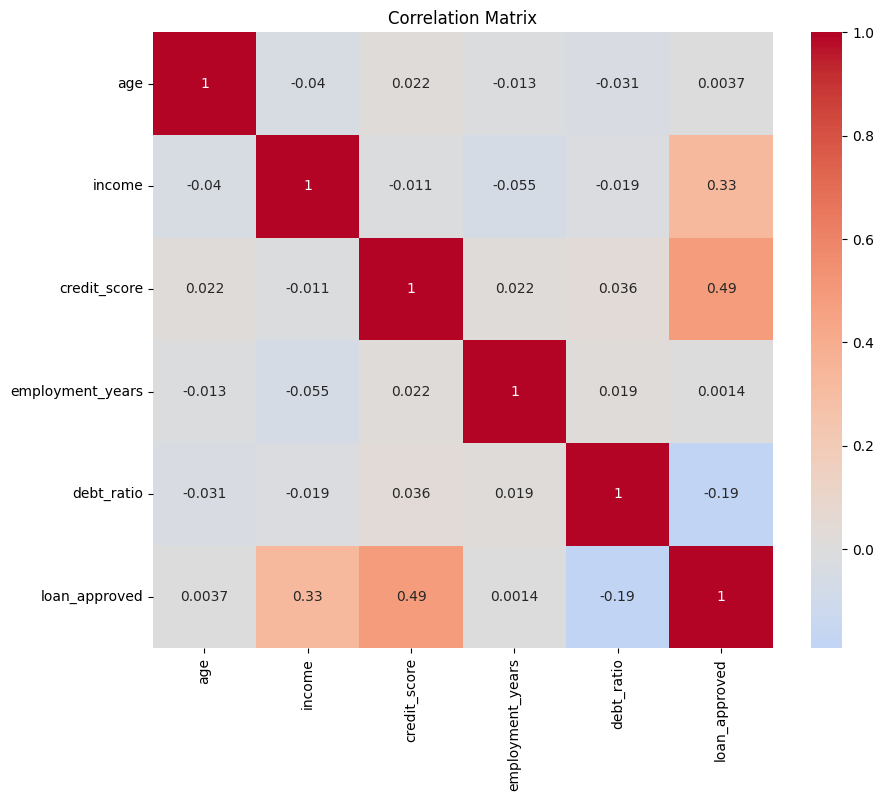

In [101]:
# Mapa de calor de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt

<function matplotlib.pyplot.tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)>

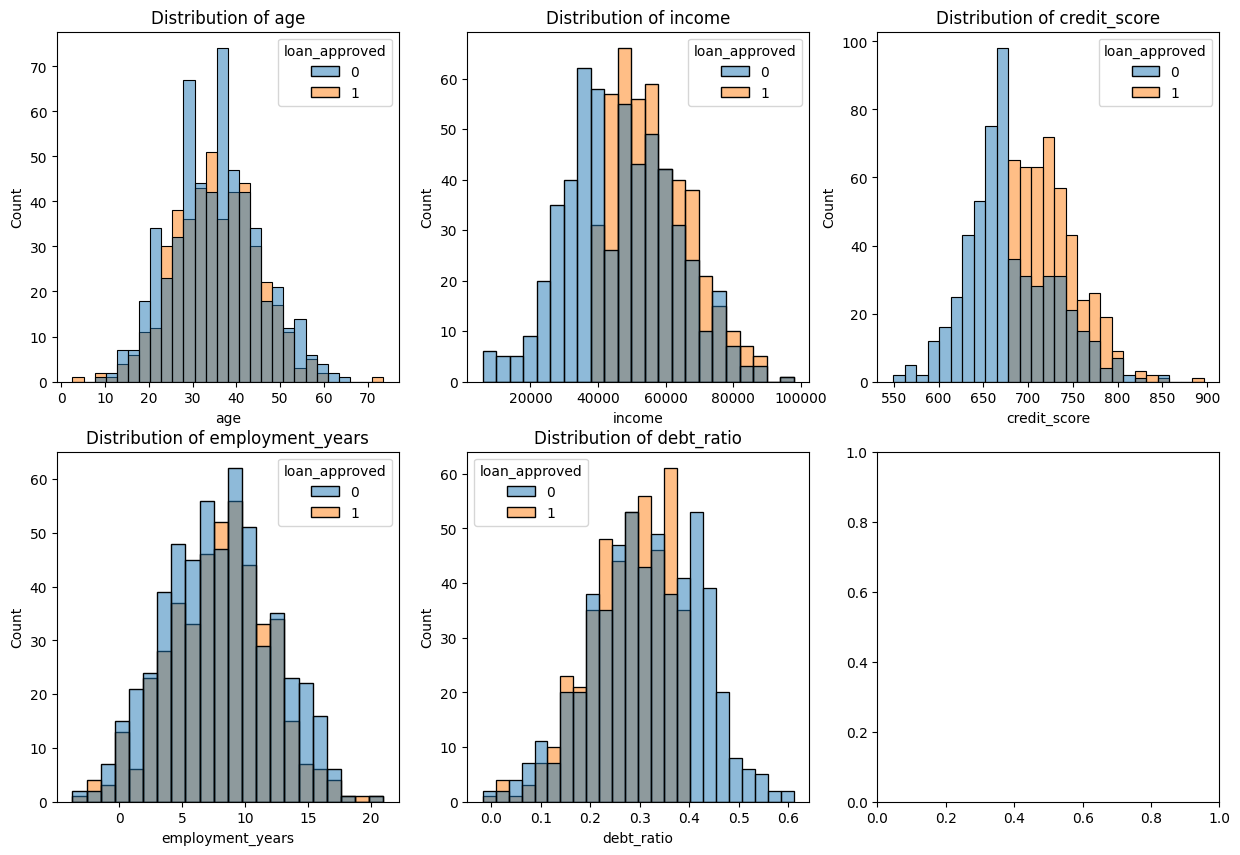

In [102]:
# Gráficos de distribuição
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    if col != 'loan_approved':
        sns.histplot(data=df, x=col, hue='loan_approved', ax=axes[idx])
        axes[idx].set_title(f'Distribution of {col}')

plt.tight_layout

## Model Development
Let's build a Random Forest model to predict

In [105]:
# Preparar recursos e alvos
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

# Dividir os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dimensione os recursos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [107]:
# Treinar modelo de floresta aleatória
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Faça previsões
y_pred = rf_model.predict(X_test)

/home/fabio/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       108
           1       0.46      1.00      0.63        92

    accuracy                           0.46       200
   macro avg       0.23      0.50      0.32       200
weighted avg       0.21      0.46      0.29       200



/home/fabio/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fabio/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fabio/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<function matplotlib.pyplot.show(close=None, block=None)>

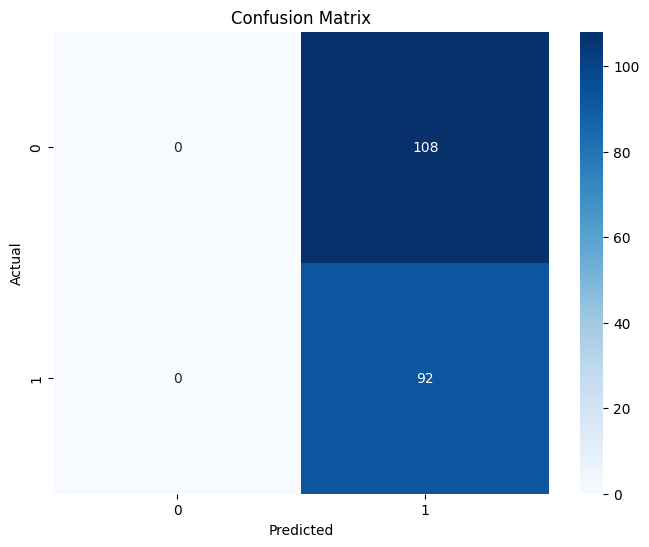

In [108]:
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

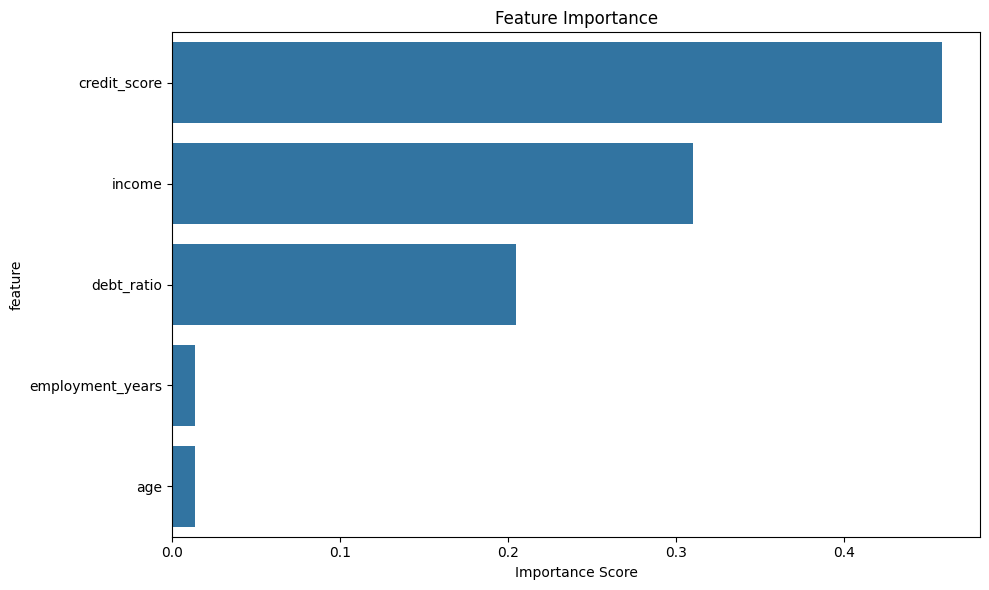

In [109]:
# Feature importance plot
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='importance', y='feature')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()

### Salvar o arquivo do modelo treinado

In [110]:
import pickle

# Save the trained model to a file
with open('credit_scoring_model.pkl', 'wb') as model_file:
    pickle.dump(rl, model_file)

# Optional: Save model parameters as a separate JSON file for reference
import json
model_params = {
    'formula': formula,
    'coefficients': dict(zip(rl.params.index, rl.params.values)),
    'aic': rl.aic,
    'bic': rl.bic
}

with open('model_parameters.json', 'w') as params_file:
    json.dump(model_params, params_file, indent=4)

/home/fabio/anaconda3/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


# Projeto Final

1. Subir no GITHUB todos os jupyter notebooks/códigos que você desenvolveu nesse ultimo módulo
1. Gerar um arquivo python (.py) com todas as funções necessárias para rodar no streamlit a escoragem do arquivo de treino
    - Criar um .py
    - Criar um carregador de csv no streamlit 
    - Subir um csv no streamlit 
    - Criar um pipeline de pré processamento dos dados
    - Utilizar o modelo treinado para escorar a base 
        - nome_arquivo = 'model_final.pkl'
1. Gravar um vídeo da tela do streamlit em funcionamento (usando o próprio streamlit (temos aula disso) ou qlqr outra forma de gravação).
1. Subir no Github o vídeo de funcionamento da ferramenta como README.md.
1. Subir no Github os códigos desenvolvidos. 
1. Enviar links do github para o tutor corrigir.